Training models...
All models trained!

Feature Importances:
              Decision Tree  Random Forest  XGBoost
Feature                                            
Amount               0.6585         0.3848   0.4103
Hour                 0.0493         0.1250   0.0533
Day of Week          0.0033         0.0154   0.0278
Is Weekend           0.0001         0.0017   0.0035
Is Night             0.0893         0.0954   0.3091
Age                  0.0154         0.0260   0.0144
Amount (Log)         0.0867         0.2428   0.1046
Category             0.0945         0.0927   0.0596
State                0.0028         0.0161   0.0174


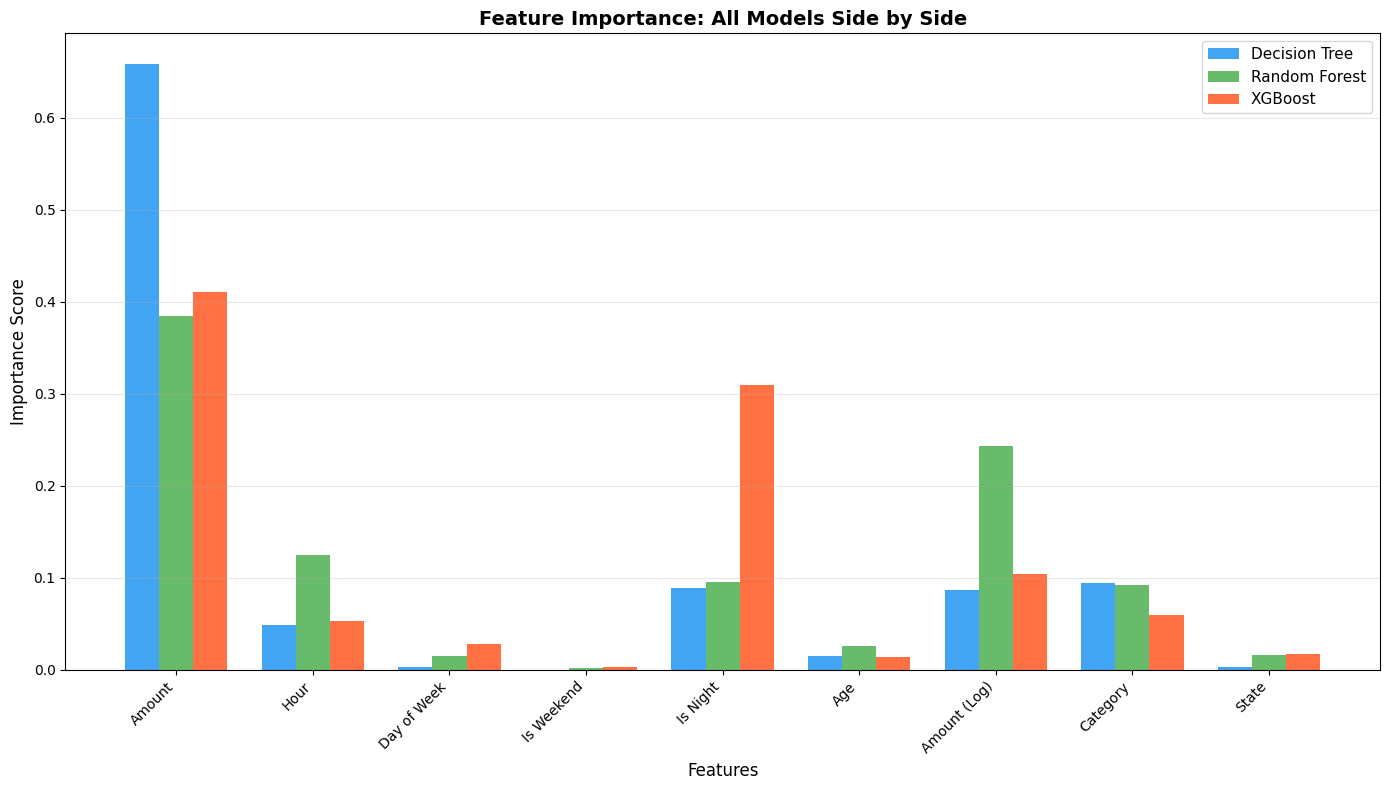

Feature importance for each model complete


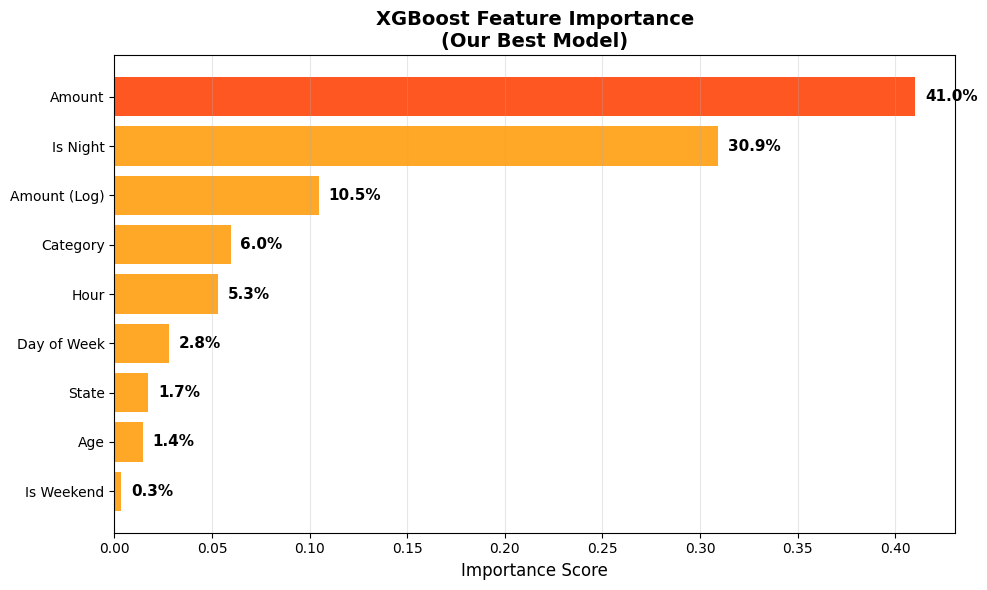

XGBoost graph complete
Rank of feature importance for each model

KEY FINDINGS:

Decision Tree:
  #1 Feature: Amount (65.9%)
  #1: Amount (65.9%)
  #2: Category (9.4%)
  #3: Is Night (8.9%)
  #4: Amount (Log) (8.7%)
  #5: Hour (4.9%)
  #6: Age (1.5%)
  #7: Day of Week (0.3%)
  #8: State (0.3%)
  #9: Is Weekend (0.0%)

Random Forest:
  #1 Feature: Amount (38.5%)
  #1: Amount (38.5%)
  #2: Amount (Log) (24.3%)
  #3: Hour (12.5%)
  #4: Is Night (9.5%)
  #5: Category (9.3%)
  #6: Age (2.6%)
  #7: State (1.6%)
  #8: Day of Week (1.5%)
  #9: Is Weekend (0.2%)

XGBoost:
  #1 Feature: Amount (41.0%)
  #1: Amount (41.0%)
  #2: Is Night (30.9%)
  #3: Amount (Log) (10.5%)
  #4: Category (6.0%)
  #5: Hour (5.3%)
  #6: Day of Week (2.8%)
  #7: State (1.7%)
  #8: Age (1.4%)
  #9: Is Weekend (0.3%)


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/raw/creditcard.csv')

df['trans_datetime'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_datetime'].dt.hour
df['day_of_week'] = df['trans_datetime'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 6)).astype(int)
df['dob_datetime'] = pd.to_datetime(df['dob'])
df['age'] = df['trans_datetime'].dt.year - df['dob_datetime'].dt.year
df['amt_log'] = np.log1p(df['amt'])

le_category = LabelEncoder()
le_state = LabelEncoder()
df['category_encoded'] = le_category.fit_transform(df['category'])
df['state_encoded'] = le_state.fit_transform(df['state'])

features = ['amt', 'hour', 'day_of_week', 'is_weekend', 'is_night', 
            'age', 'amt_log', 'category_encoded', 'state_encoded']

feature_labels = ['Amount', 'Hour', 'Day of Week', 'Is Weekend', 
                  'Is Night', 'Age', 'Amount (Log)', 'Category', 'State']

X = df[features]
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Training models...")

dt = DecisionTreeClassifier(random_state=42, max_depth=10, class_weight='balanced')
dt.fit(X_train_res, y_train_res)

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_res, y_train_res)

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train_res, y_train_res)

print("All models trained!")

dt_imp = dt.feature_importances_
rf_imp = rf.feature_importances_
xgb_imp = xgb.feature_importances_


importance_df = pd.DataFrame({
    'Feature': feature_labels,
    'Decision Tree': dt_imp,
    'Random Forest': rf_imp,
    'XGBoost': xgb_imp
})

importance_df = importance_df.set_index('Feature')

print("\nFeature Importances:")
print(importance_df.round(4))

# Bar Chart graph of feature importance for each model 
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(feature_labels))
width = 0.25

bars1 = ax.bar(x - width, dt_imp, width, label='Decision Tree', 
               color='#2196F3', alpha=0.85)
bars2 = ax.bar(x, rf_imp, width, label='Random Forest', 
               color='#4CAF50', alpha=0.85)
bars3 = ax.bar(x + width, xgb_imp, width, label='XGBoost', 
               color='#FF5722', alpha=0.85)

ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Importance Score', fontsize=12)
ax.set_title('Feature Importance: All Models Side by Side', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(feature_labels, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/plots/feature_importance_grouped.png', 
            dpi=300, bbox_inches='tight')
plt.show()
print("Feature importance for each model complete")

#XGBoost graph (our best model with a 0.80 F1-Score)
fig, ax = plt.subplots(figsize=(10, 6))

sorted_xgb = importance_df['XGBoost'].sort_values(ascending=True)
colors_xgb = ['#FF5722' if v == sorted_xgb.max() else '#FFA726' 
               for v in sorted_xgb.values]

bars = ax.barh(sorted_xgb.index, sorted_xgb.values, color=colors_xgb)

ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('XGBoost Feature Importance\n(Our Best Model)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add percentage labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2,
            f'{width*100:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/plots/feature_importance_xgboost.png', 
            dpi=300, bbox_inches='tight')
plt.show()
print("XGBoost graph complete")

print("Rank of feature importance for each model")
print("\n" + "="*50)
print("KEY FINDINGS:")
print("="*50)
for model in ['Decision Tree', 'Random Forest', 'XGBoost']:
    top = importance_df[model].idxmax()
    top_val = importance_df[model].max()
    print(f"\n{model}:")
    print(f"  #1 Feature: {top} ({top_val*100:.1f}%)")
    ranked = importance_df[model].sort_values(ascending=False)
    for i, (feat, val) in enumerate(ranked.items(), 1):
        print(f"  #{i}: {feat} ({val*100:.1f}%)")